In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("sid321axn/beijing-multisite-airquality-data-set")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'beijing-multisite-airquality-data-set' dataset.
Path to dataset files: /kaggle/input/beijing-multisite-airquality-data-set


In [5]:
import os
import glob
import csv
import pandas as pd
import numpy as np
import missingno as msno
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
import keras_tuner as kt
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

In [6]:
tf.random.set_seed(4) # Just a seed for reproducability

In [7]:
# READ from KaggleHub dataset (read-only)
input_path = path   # "/kaggle/input/beijing-multisite-airquality-data-set"

# WRITE to Colab working directory (writable)
output_path = "/content"
output_file = os.path.join(output_path, "beijing_all_stations.csv")

if not os.path.exists(output_file):

    csv_files = glob.glob(os.path.join(input_path, "*.csv"))

    dfs = []
    for file in csv_files:
        dfs.append(pd.read_csv(file))

    df = pd.concat(dfs, ignore_index=True)

    if 'No' in df.columns:
        df = df.drop(columns=['No', 'PM10'])

    df.to_csv(output_file, index=False, quoting=csv.QUOTE_ALL)

    print(f"Combined CSV saved to: {output_file}")
    print(f"Shape of combined dataset: {df.shape}")

else:
    df = pd.read_csv(output_file)
    print(f"File already exists at '{output_file}'. Skipping concatenation.")

Combined CSV saved to: /content/beijing_all_stations.csv
Shape of combined dataset: (420768, 16)


In [8]:
df['datetime'] = pd.to_datetime(df[['year', 'month', 'day', 'hour']])

# Sort by station and time
df = df.sort_values(['station', 'datetime'])
df = df.drop(columns=['year', 'month', 'day', 'hour'])
df.head()

,PM2.5,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station,datetime
35064,4.0,4.0,7.0,300.0,77.0,-0.7,1023.0,-18.8,0.0,NNW,4.4,Aotizhongxin,2013-03-01 00:00:00
35065,8.0,4.0,7.0,300.0,77.0,-1.1,1023.2,-18.2,0.0,N,4.7,Aotizhongxin,2013-03-01 01:00:00
35066,7.0,5.0,10.0,300.0,73.0,-1.1,1023.5,-18.2,0.0,NNW,5.6,Aotizhongxin,2013-03-01 02:00:00
35067,6.0,11.0,11.0,300.0,72.0,-1.4,1024.5,-19.4,0.0,NW,3.1,Aotizhongxin,2013-03-01 03:00:00
35068,3.0,12.0,12.0,300.0,72.0,-2.0,1025.2,-19.5,0.0,N,2.0,Aotizhongxin,2013-03-01 04:00:00


In [9]:
cols = ['PM2.5','SO2','NO2','CO','O3','TEMP','PRES','DEWP','RAIN','WSPM']

df_clean = df.sort_values(['station', 'datetime'])

df_clean[cols] = (df_clean.groupby('station')[cols].transform(lambda g: g.interpolate()))

# handle edge NaNs (when they are at the start or the end)
df_clean[cols] = df_clean[cols].ffill().bfill()

In [10]:
# Best guess for wind direction would be that the missing is still the same as the last hour (forward fill)
df_clean['wd'] = (df_clean.sort_values(['station', 'datetime']).groupby('station')['wd'].ffill())

df_clean['wd'] = df_clean.groupby('station')['wd'].bfill() # Simply if we have missing values at the start, remaining NaN's

In [11]:
# map directions to degrees
wd_map = {'N':0, 'NNE':22.5, 'NE':45, 'ENE':67.5, 'E':90, 'ESE':112.5, 'SE':135, 'SSE':157.5,
    'S':180, 'SSW':202.5, 'SW':225, 'WSW':247.5, 'W':270, 'WNW':292.5, 'NW':315, 'NNW':337.5
}

df_clean['wd_deg'] = df_clean['wd'].map(wd_map)
df_clean['wd_sin'] = np.sin(np.deg2rad(df_clean['wd_deg']))
df_clean['wd_cos'] = np.cos(np.deg2rad(df_clean['wd_deg']))
df_clean = df_clean.drop(columns=['wd','wd_deg'])

In [12]:
# extract hour of day (0–23) and day of year (1–365)
df_clean['hour'] = df_clean['datetime'].dt.hour
df_clean['day_of_year'] = df_clean['datetime'].dt.dayofyear

# daily cycle
df_clean['hour_sin'] = np.sin(2 * np.pi * df_clean['hour'] / 24)
df_clean['hour_cos'] = np.cos(2 * np.pi * df_clean['hour'] / 24)

# yearly/seasonal cycle
df_clean['doy_sin'] = np.sin(2 * np.pi * df_clean['day_of_year'] / 365)
df_clean['doy_cos'] = np.cos(2 * np.pi * df_clean['day_of_year'] / 365)

# drop temporary numeric columns
df_clean = df_clean.drop(columns=['hour','day_of_year'])

<Axes: >

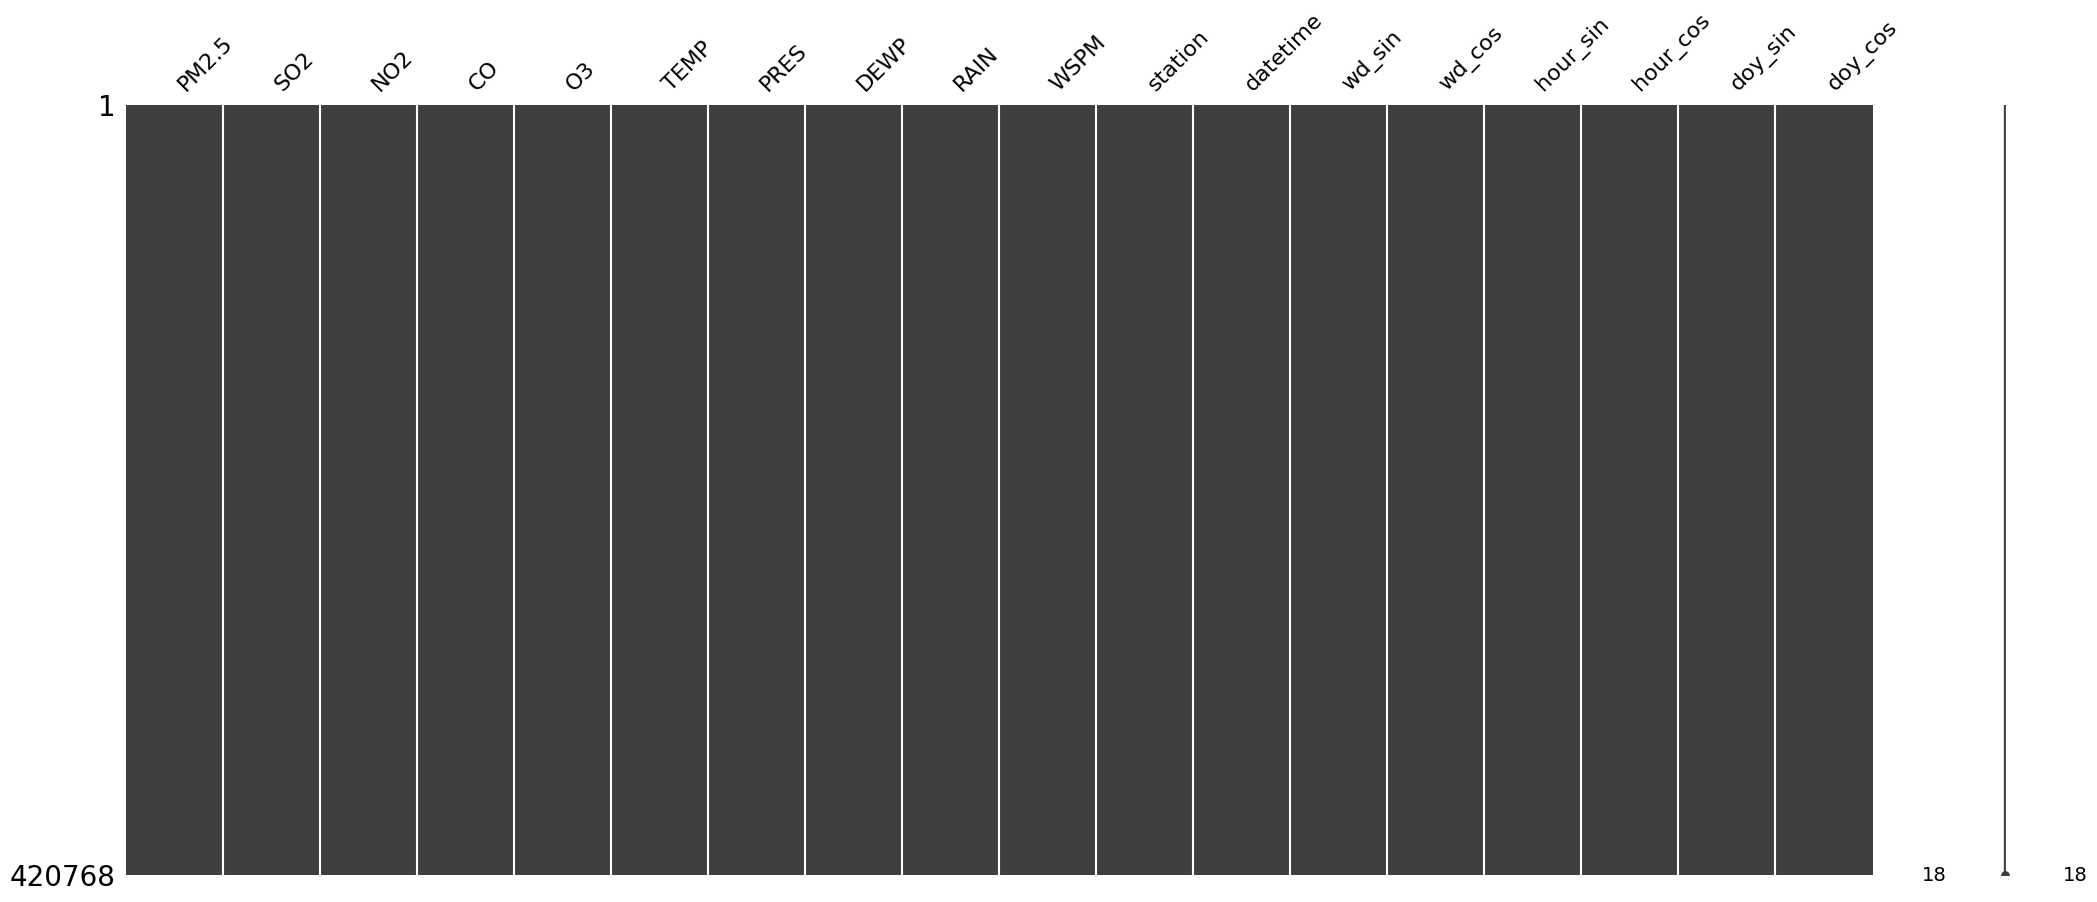

In [13]:
msno.matrix(df_clean)

In [14]:
# Training on one station
df_model = df_clean[df_clean['station'] == 'Aotizhongxin'].copy()

# Drop non-numerical columns we don't need anymore
df_model = df_model.drop(columns=['station', 'datetime'])

In [15]:
df_model = df_model.astype('float32')
df_model.dtypes

,0
PM2.5,float32
SO2,float32
NO2,float32
CO,float32
O3,float32
TEMP,float32
PRES,float32
DEWP,float32
RAIN,float32
WSPM,float32


In [16]:
data_values = df_model.values

scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data_values)

target_col_index = 0

In [17]:
# This is just needed because we need 3D data
# Also the target variable is ready for future predictions
def create_lstm_sequences(data, seq_length, target_idx):
    X = []
    y = []

    # Iterate through the data
    for i in range(len(data) - seq_length):
        # Gather the past 24 hours of ALL features
        # Shape: (24, 18) -> (Hours, Features)
        X.append(data[i:i+seq_length])

        # Gather the target: PM2.5 at the NEXT hour (i + seq_length)
        y.append(data[i+seq_length, target_idx])

    return np.array(X), np.array(y)

# Create the 3D Arrays
SEQ_LENGTH = 24
X_lstm, y_lstm = create_lstm_sequences(scaled_data, seq_length=SEQ_LENGTH, target_idx=0)

print(f"Input Shape (X): {X_lstm.shape}")

Input Shape (X): (35040, 24, 16)


In [18]:
split_idx = int(len(X_lstm) * 0.8)
X_train, X_test = X_lstm[:split_idx], X_lstm[split_idx:]
y_train, y_test = y_lstm[:split_idx], y_lstm[split_idx:]

In [19]:
def build_model(hp):
    model = Sequential()

    model.add(LSTM(
        units=hp.Int('units', 32, 128, step=32),
        input_shape=(X_train.shape[1], X_train.shape[2])
    ))

    model.add(Dropout(0.2))
    model.add(Dense(1))

    model.compile(
        optimizer=Adam(hp.Choice('learning_rate', [1e-2, 1e-3, 1e-4])),
        loss='mse',
        metrics=['mae']
    )
    return model

# Use Hyperband (Smarter/Faster than RandomSearch)
tuner = kt.Hyperband(
    build_model,
    objective='val_loss',
    max_epochs=20,
    directory='tuning_dir',
    project_name='air_quality_dynamic'
)

early_stopping = EarlyStopping(
    monitor='val_loss', # Watch the validation loss
    patience=3, # Wait 3 epochs after it stops improving
    restore_best_weights=True # Go back to the best version found
)

# Run Search
tuner.search(
    X_train, y_train,
    epochs = 20,
    validation_split=0.2,
    callbacks=[early_stopping],
    verbose = 1
)

best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

print(f"""
The optimal number of units is {best_hps.get('units')}
and the optimal learning rate is {best_hps.get('learning_rate')}.
""")

Trial 18 Complete [00h 00m 19s]
val_loss: 0.0007780866581015289

Best val_loss So Far: 0.0006377989193424582
Total elapsed time: 00h 05m 22s

The optimal number of units is 32 
and the optimal learning rate is 0.01.



In [38]:
final_model = tuner.hypermodel.build(best_hps) # Retrieve the tuned model

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

history = final_model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=50,
    batch_size=64,
    callbacks=[early_stopping],
    verbose=1
)

test_loss, test_mae = final_model.evaluate(X_test, y_test)
print(f"Final Test MAE: {test_mae}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
438/438 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 0.0058 - mae: 0.0464 - val_loss: 4.9941e-04 - val_mae: 0.0140
Epoch 2/50
438/438 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 7.5226e-04 - mae: 0.0183 - val_loss: 4.8126e-04 - val_mae: 0.0145
Epoch 3/50
438/438 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.5728e-04 - mae: 0.0165 - val_loss: 4.3496e-04 - val_mae: 0.0130
Epoch 4/50
438/438 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.1588e-04 - mae: 0.0158 - val_loss: 3.8759e-04 - val_mae: 0.0112
Epoch 5/50
438/438 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 5.8640e-04 - mae: 0.0154 - val_loss: 5.2272e-04 - val_mae: 0.0162
Epoch 6/50
438/438 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 5.8628e-04 - mae: 0.0153 - val_loss: 3.9879e-04 - val_mae: 0.0116
Epoch 7/50
438/438 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 5.7253e-04 - mae: 0.0151 - val_loss: 4.5739e-04 - val_mae: 0.0140
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 2.2383e-04 - mae: 0.0095
Final Test MAE: 0.011234883219003677


In [39]:
print(final_model.metrics_names)

['loss', 'compile_metrics']


In [22]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. Make Predictions (Output is between 0 and 1)
y_pred_scaled =final_model.predict(X_test)

# 2. Create a dummy array with the same shape as original data (18 columns)
# We fill it with zeros, then place our predictions in the PM2.5 column (index 0)
dummy_array = np.zeros((len(y_pred_scaled), 16)) # 18 = number of features you scaled originally
dummy_array[:, 0] = y_pred_scaled.flatten() # Fill 1st column with predictions

# 3. Inverse Transform
# We get back 18 columns, but we only care about the first one
y_pred_real = scaler.inverse_transform(dummy_array)[:, 0]

# 4. Do the same for y_test (Actual values) to compare apples-to-apples
dummy_y_test = np.zeros((len(y_test), 16))
dummy_y_test[:, 0] = y_test
y_test_real = scaler.inverse_transform(dummy_y_test)[:, 0]

rmse = np.sqrt(mean_squared_error(y_test_real, y_pred_real))
mae = mean_absolute_error(y_test_real, y_pred_real)
r_squared = r2_score(y_test_real, y_pred_real)

print(f"Real RMSE: {rmse}")
print(f"R squared: {r_squared}")
print(f"Mean absolute error: {mae}")

219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Real RMSE: 17.752640537061637
R squared: 0.954922716507759
Mean absolute error: 10.230148814059344


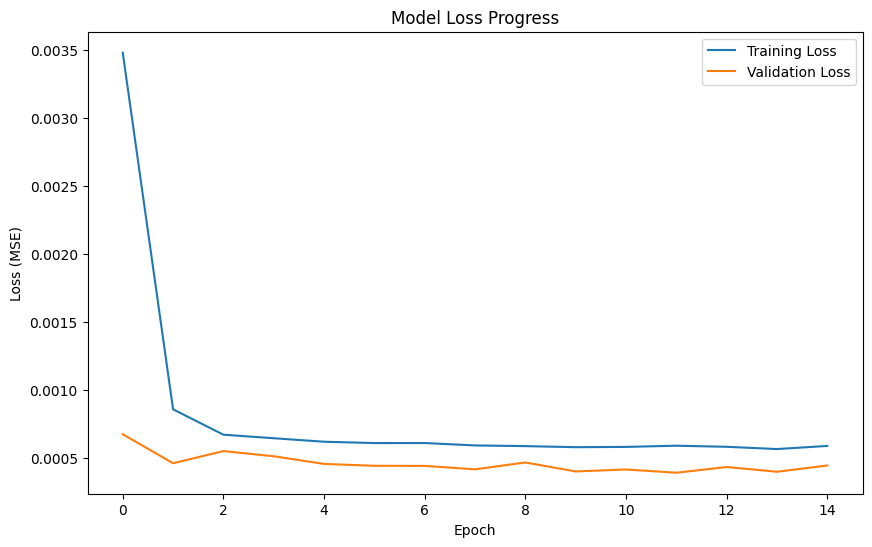

In [23]:
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss Progress')
plt.ylabel('Loss (MSE)')
plt.xlabel('Epoch')
plt.legend()
plt.show()

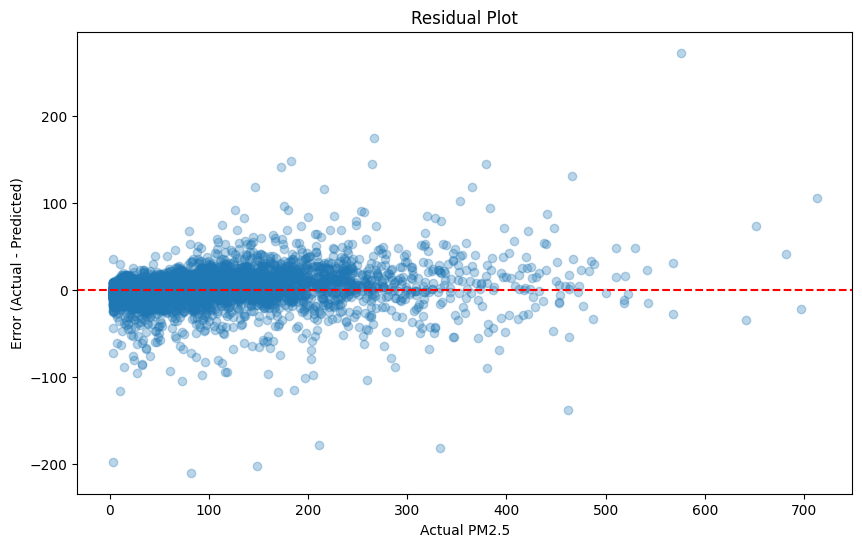

In [24]:
residuals = y_test_real - y_pred_real

plt.figure(figsize=(10, 6))
plt.scatter(y_test_real, residuals, alpha=0.3)
plt.axhline(0, color='r', linestyle='--')
plt.xlabel('Actual PM2.5')
plt.ylabel('Error (Actual - Predicted)')
plt.title('Residual Plot')
plt.show()

In [29]:
df_clean['station'].unique()

array(['Aotizhongxin', 'Changping', 'Dingling', 'Dongsi', 'Guanyuan',
       'Gucheng', 'Huairou', 'Nongzhanguan', 'Shunyi', 'Tiantan',
       'Wanliu', 'Wanshouxigong'], dtype=object)

In [34]:
df_test_fit = df_clean[df_clean['station'] == 'Tiantan'].copy()
df_test_fit = df_test_fit.drop(columns=['station', 'datetime'])
df_test_fit = df_test_fit .astype('float32')
df_test_fit.dtypes

,0
PM2.5,float32
SO2,float32
NO2,float32
CO,float32
O3,float32
TEMP,float32
PRES,float32
DEWP,float32
RAIN,float32
WSPM,float32


In [35]:
data_values = df_test_fit.values

scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data_values)

target_col_index = 0

In [36]:
# Create the 3D Arrays
SEQ_LENGTH = 24
X_new_lstm, y_new_lstm = create_lstm_sequences(scaled_data, seq_length=SEQ_LENGTH, target_idx=0)

print(f"Input Shape (X): {X_new_lstm.shape}")

Input Shape (X): (35040, 24, 16)


In [37]:

y_pred_scaled =final_model.predict(X_new_lstm)

dummy_array = np.zeros((len(y_pred_scaled), 16))
dummy_array[:, 0] = y_pred_scaled.flatten()

y_pred_real = scaler.inverse_transform(dummy_array)[:, 0]

dummy_y_test = np.zeros((len(y_new_lstm), 16))
dummy_y_test[:, 0] = y_new_lstm
y_test_real = scaler.inverse_transform(dummy_y_test)[:, 0]

rmse = np.sqrt(mean_squared_error(y_test_real, y_pred_real))
mae = mean_absolute_error(y_test_real, y_pred_real)
r_squared = r2_score(y_test_real, y_pred_real)

print(f"Real RMSE: {rmse}")
print(f"R squared: {r_squared}")
print(f"Mean absolute error: {mae}")

1095/1095 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
Real RMSE: 17.675683108769096
R squared: 0.95226199776495
Mean absolute error: 10.580962455173346
